In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
movies = pd.read_csv('data/movies.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Movies shape:", movies.shape)
print("\nTrain sample:")
train.head()

Train shape: (10000038, 4)
Test shape: (5000019, 2)
Movies shape: (62423, 3)

Train sample:


,userId,movieId,rating,timestamp
0,5163,57669,4.0,1518349992
1,106343,5,4.5,1206238739
2,146790,5459,5.0,1076215539
3,106362,32296,2.0,1423042565
4,9041,366,3.0,833375837


In [4]:
## Getting the basic statistiques of the dataset
print("Rating Distribution:")
print(train['rating'].describe())
print("\nUnique users:", train['userId'].nunique())
print("Unique movies:", train['movieId'].nunique())
print("Total ratings:", len(train))
print("\nRating value counts:")
print(train['rating'].value_counts().sort_index())

Rating Distribution:
count    1.000004e+07
mean     3.533395e+00
std      1.061124e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Unique users: 162541
Unique movies: 48213
Total ratings: 10000038

Rating value counts:
rating
0.5     157571
1.0     311213
1.5     159731
2.0     656821
2.5     505578
3.0    1959759
3.5    1270642
4.0    2652977
4.5     880516
5.0    1445230
Name: count, dtype: int64


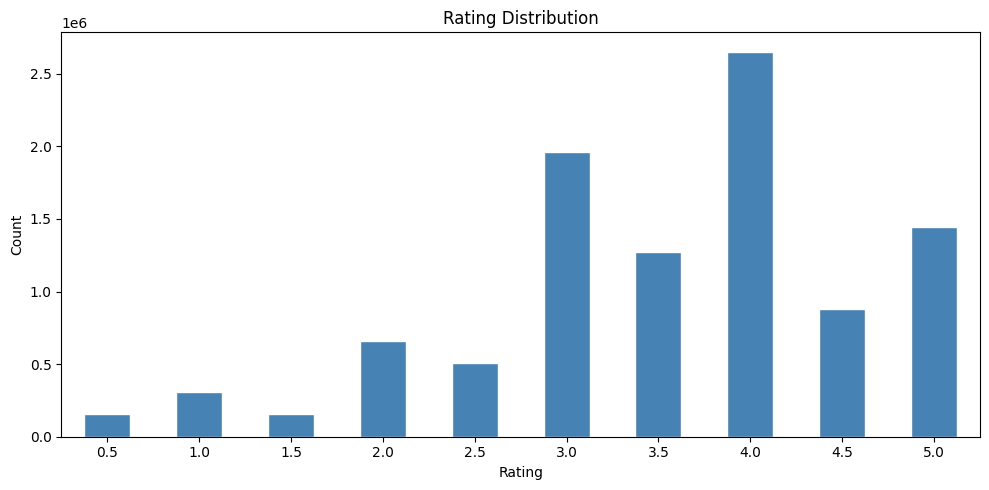

In [ ]:
## Rating distribution plot
plt.figure(figsize=(10, 5))
train['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

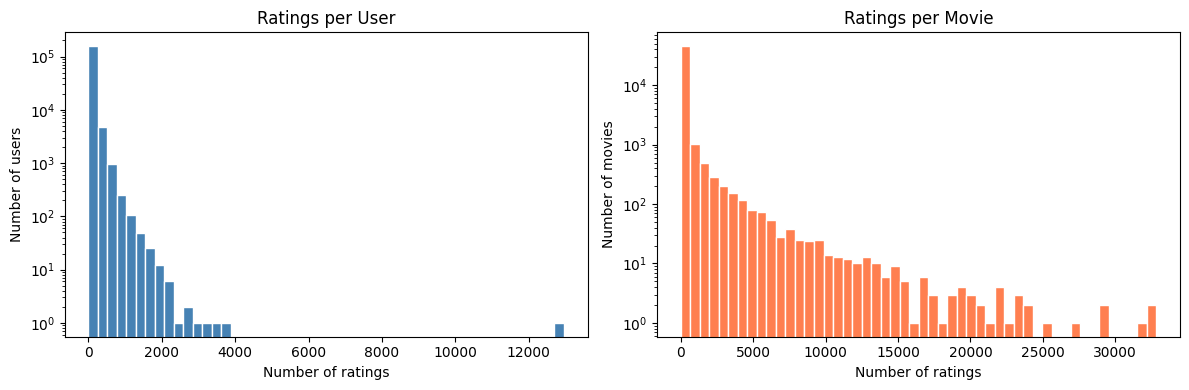

Most active user rated 12952 movies
Least active user rated 1 movies
Most rated movie has 32831 ratings
Least rated movie has 1 ratings

Median ratings per user: 28.0
Median ratings per movie: 4.0


In [6]:
user_counts = train.groupby('userId')['rating'].count()
movie_counts = train.groupby('movieId')['rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(user_counts, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Ratings per User')
axes[0].set_xlabel('Number of ratings')
axes[0].set_ylabel('Number of users')
axes[0].set_yscale('log')

axes[1].hist(movie_counts, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Ratings per Movie')
axes[1].set_xlabel('Number of ratings')
axes[1].set_ylabel('Number of movies')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Most active user rated {user_counts.max()} movies")
print(f"Least active user rated {user_counts.min()} movies")
print(f"Most rated movie has {movie_counts.max()} ratings")
print(f"Least rated movie has {movie_counts.min()} ratings")
print(f"\nMedian ratings per user: {user_counts.median()}")
print(f"Median ratings per movie: {movie_counts.median()}")

In [7]:
"""Baseline model (global mean + user bias + movie bias)
This is our first real model. It's simple but surprisingly strong — many Kaggle winners use this as a component even in their final ensemble.
The idea: predict each rating as global_mean + user_bias + movie_bias. 
User bias captures whether a user rates high or low generally. Movie bias captures whether a movie is rated high or low generally."""

# Global mean
global_mean = train['rating'].mean()
print(f"Global mean rating: {global_mean:.4f}")

# User bias — how much each user deviates from global mean on average
user_bias = train.groupby('userId')['rating'].mean() - global_mean

# Movie bias — how much each movie deviates from global mean on average
movie_bias = train.groupby('movieId')['rating'].mean() - global_mean

print(f"\nUser bias range: {user_bias.min():.3f} to {user_bias.max():.3f}")
print(f"Movie bias range: {movie_bias.min():.3f} to {movie_bias.max():.3f}")


Global mean rating: 3.5334

User bias range: -3.033 to 1.467
Movie bias range: -3.033 to 1.467


In [8]:
## Generate predicitions and submission file 

# Load test file
test = pd.read_csv('data/test.csv')

# Map biases onto test set
test['user_bias'] = test['userId'].map(user_bias).fillna(0)
test['movie_bias'] = test['movieId'].map(movie_bias).fillna(0)

# Predict
test['rating'] = global_mean + test['user_bias'] + test['movie_bias']

# Clip to valid rating range
test['rating'] = test['rating'].clip(0.5, 5.0)

# Build submission
test['Id'] = test['userId'].astype(str) + '_' + test['movieId'].astype(str)
submission = test[['Id', 'rating']]

submission.to_csv('data/submission_baseline.csv', index=False)
print("Submission file saved")
print(f"Shape: {submission.shape}")
print(f"\nSample predictions:")
submission.head(10)


Submission file saved
Shape: (5000019, 2)

Sample predictions:


,Id,rating
0,1_2011,3.926269
1,1_4144,4.421179
2,1_5767,3.932875
3,1_6711,4.164132
4,1_7318,3.487435
5,1_8405,4.071398
6,1_8786,4.221581
7,2_150,3.746887
8,2_356,3.930488
9,2_497,3.765551
